In [1]:
import nltk
import string
import pandas as pd

from pandas import DataFrame
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

In [2]:
contents = [
    "The ingredients of machine learning",
    "Binary classification and related tasks",
    "Beyond binary classification",
    "Concept learning",
    "Tree models",
    "Rule models",
    "Linear models",
    "Distance-based models",
    "Probabilistic models",
    "Features",
    "Model ensembles",
    "Machine learning experiments",
    "Representations"
] 

contents = [chapter_name.lower() for chapter_name in contents]

paragraphs = [
    "We could approach this as a combination of two binary classification tasks: the first task is to distinguish between spam and ham, and the second task is, among ham e-mails, to distinguish between work-related and private ones. However, some potentially useful information may get lost this way, as some spam e-mails tend to look like private rather than work-related messages.",
    "It constitutes a binary classification task, which is easily the most common task in machine learning which figures heavily throughout the book.",
    "Two-class classification is often called binary classification (or concept learning, if the positive class can be meaningfully called a concept)",
    "In Classification we defined the binary classification task and introduced an important tool to assess performance at such a task, namely the two-by-two contingency table."
]

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/daladier/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/daladier/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/daladier/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words('english'))

corpus = "" 

for sentence in contents:
    corpus += sentence + " "

corpus = word_tokenize(corpus)
corpus = list(set(word for word in corpus if word not in stop_words))

vocab = {}

for idx, word in enumerate(corpus, 0):
    if word not in vocab.keys():
        vocab[word]= idx
vocab

{'experiments': 0,
 'linear': 1,
 'classification': 2,
 'learning': 3,
 'representations': 4,
 'ensembles': 5,
 'rule': 6,
 'binary': 7,
 'concept': 8,
 'probabilistic': 9,
 'machine': 10,
 'tasks': 11,
 'tree': 12,
 'distance-based': 13,
 'models': 14,
 'model': 15,
 'beyond': 16,
 'features': 17,
 'related': 18,
 'ingredients': 19}

In [5]:
def remove_stop_words(tokenized_sentence:list) -> list:

    cleaned_words = [stemmer.stem(word) for word in tokenized_sentence if word not in stop_words and word not in string.punctuation]
    return [word for word in cleaned_words if word not in ["'", '--', '``', "''", "'s"]] 

In [6]:
paragraphs = [word_tokenize(paragraph) for paragraph in paragraphs]
paragraphs = [remove_stop_words(paragraph) for paragraph in paragraphs]

In [7]:
def encode_paragraphs(paragraphs: list, vocab: dict) -> list:
    
    encoded_paragraphs = []
    
    for paragraph in paragraphs:
        embedding = [0] * len(vocab)
        for word in paragraph:
            if word in vocab.keys():
                embedding[vocab[word]] = 1
        encoded_paragraphs.append(embedding)
        
    return encoded_paragraphs 

In [8]:
def generate_dataframe(encoded_paragraphs: list, vocab: dict) -> DataFrame:

    data_frame = {}

    for key, value in vocab.items():
        data_frame[key] = [paragraph[value] for paragraph in encoded_paragraphs]

    data_frame["chapter"] = [1, 1,2, 2]
    
    return pd.DataFrame.from_dict(data_frame)
    

In [9]:
encoded_paragraphs=encode_paragraphs(paragraphs, vocab)
encoded_paragraphs

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

In [10]:
data_frame = generate_dataframe(encoded_paragraphs, vocab)

In [11]:
data_frame

,experiments,linear,classification,learning,representations,ensembles,rule,binary,concept,probabilistic,...,tasks,tree,distance-based,models,model,beyond,features,related,ingredients,chapter
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,2
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


## Exploring new data and features

### Gutenberg corpus

In [12]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     /home/daladier/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     /home/daladier/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /home/daladier/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /home/daladier/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /home/daladier/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]  

True

In [13]:
from nltk.corpus import gutenberg
from nltk.tokenize import sent_tokenize

import matplotlib.pyplot as plt

print(gutenberg.fileids())

['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


This corpus contains a selection of public-domain English books, mostly from the 18th–19th centuries

In [14]:
authors = list(set([fileids.split('-')[0] for fileids in gutenberg.fileids()]))
authors

['blake',
 'burgess',
 'carroll',
 'milton',
 'whitman',
 'shakespeare',
 'austen',
 'edgeworth',
 'bible',
 'chesterton',
 'melville',
 'bryant']

In [15]:
def get_book_list_per_author(author: str) -> list:
    
    return [file for file in  gutenberg.fileids() if file.startswith(author)]

In [16]:
def book_average_sentence_length(text: str) -> float:
    sentences = sent_tokenize(text)
    
    lengths = []
    for sentence in sentences:
        words = word_tokenize(sentence)
        lengths.append(len(words))
        
    return sum(lengths)/len(lengths)    

In [17]:
def author_average_sentence_length(author: str) -> float:
    
    books = get_book_list_per_author(author)
    
    corpus = ""
    
    for book in books:
        corpus += gutenberg.raw(book)
        corpus += '\n'
        
    sentences = sent_tokenize(corpus)
    lengths = []
    
    for sentence in sentences:
        words = word_tokenize(sentence)
        lengths.append(len(words))
        
    return sum(lengths)/len(lengths)

### Features

#### Average sentence lenght - per author

In [18]:
sentence_lenght_per_author = {}

for author in authors:
    sentence_lenght_per_author[author] = author_average_sentence_length(author)

sentence_lenght_per_author

{'blake': 23.208450704225353,
 'burgess': 18.552447552447553,
 'carroll': 20.636923076923075,
 'milton': 52.16130790190736,
 'whitman': 38.99895479487849,
 'shakespeare': 15.514042867701404,
 'austen': 26.989422956565278,
 'edgeworth': 20.732765451664026,
 'bible': 31.766000268348318,
 'chesterton': 21.15314937515726,
 'melville': 25.90560292326431,
 'bryant': 20.496869244935542}

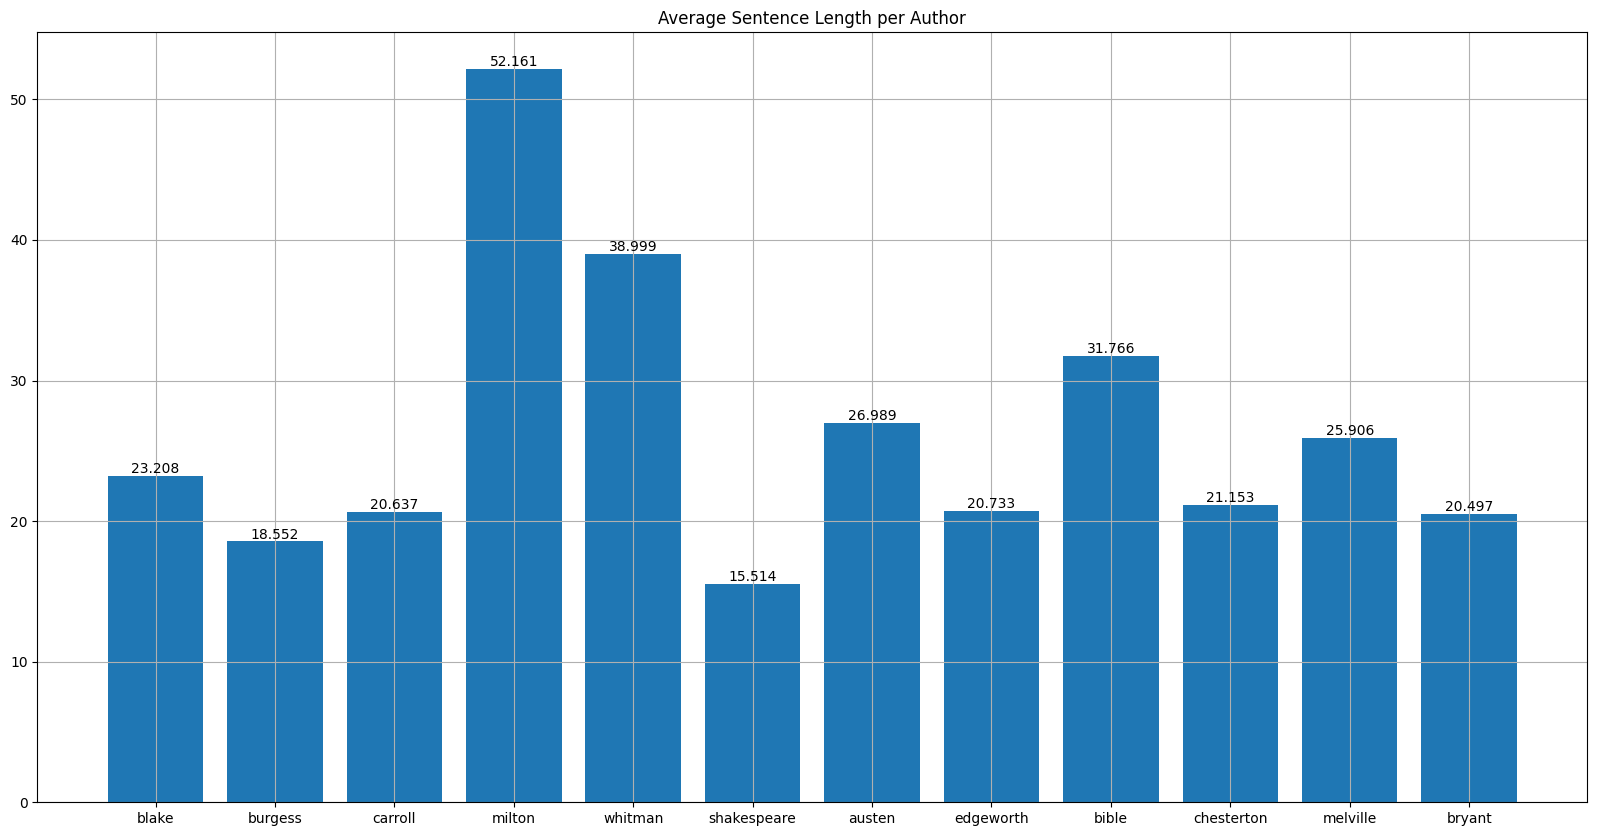

In [19]:
plt.figure(figsize=(20,10))
bars = plt.bar(sentence_lenght_per_author.keys(), sentence_lenght_per_author.values())

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{round(height, 3)}",
        ha="center",
        va="bottom"
    )
plt.title('Average Sentence Length per Author')
plt.grid(True)
plt.show()

#### Average sentence lenght - per book

In [20]:
books_by_shakespeare = get_book_list_per_author('shakespeare')

sentence_lenghts = []
for book in books_by_shakespeare:
    sentence_lenghts.append(book_average_sentence_length(gutenberg.raw(book)))


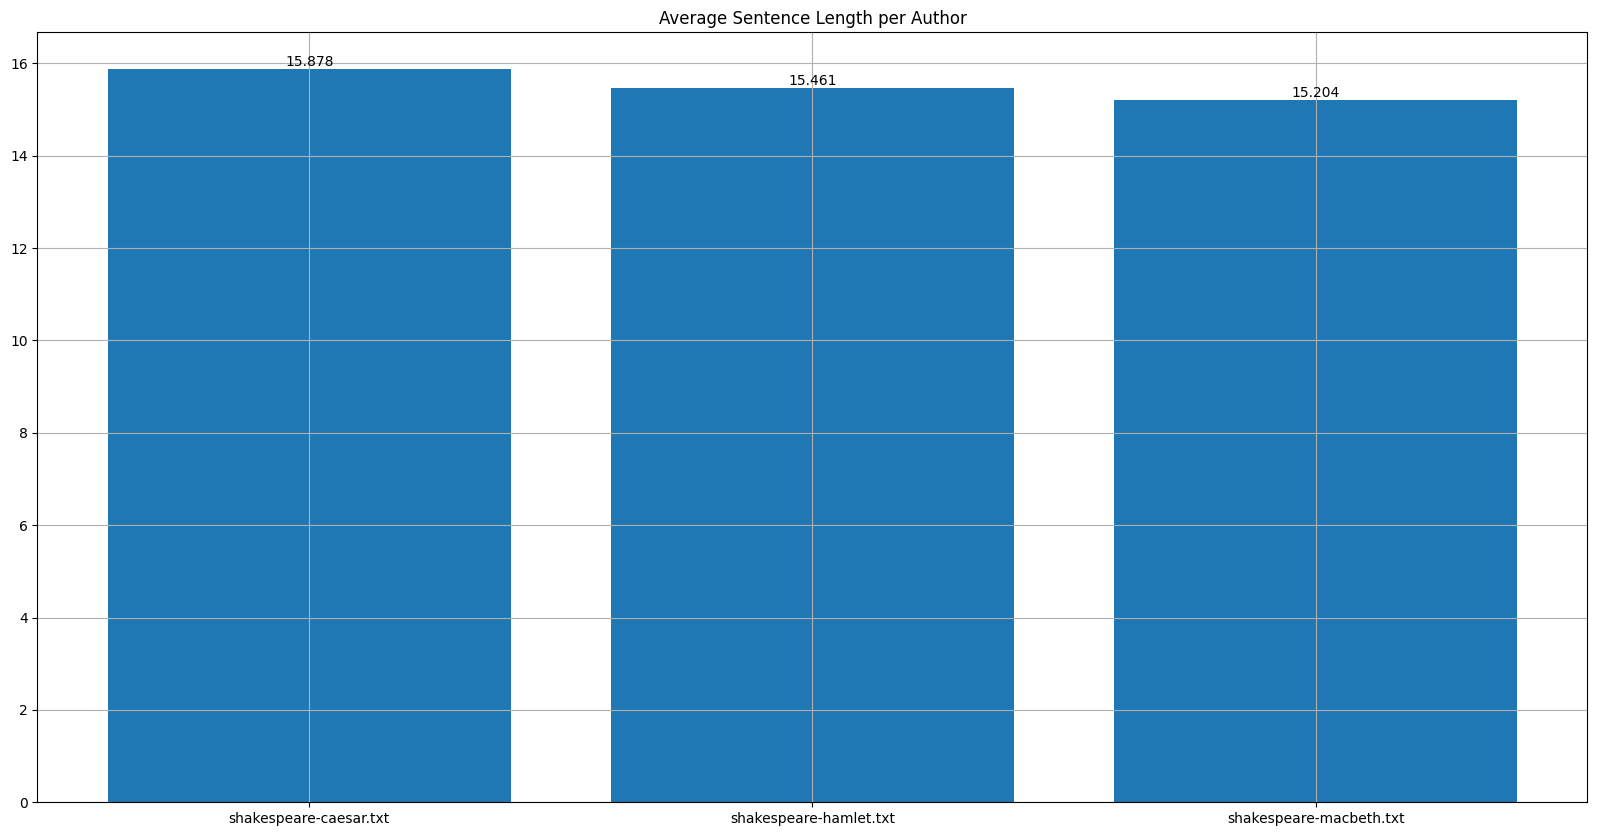

In [21]:
plt.figure(figsize=(20,10))
bars = plt.bar(books_by_shakespeare, sentence_lenghts)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{round(height, 3)}",
        ha="center",
        va="bottom"
    )
plt.title('Average Sentence Length per Author')
plt.grid(True)
plt.show()

#### Most Frequent Words

In [22]:
def preprocess(text: str) -> list:
    words = word_tokenize(text)

    return remove_stop_words(words)

In [23]:
from collections import defaultdict 


books_per_author = defaultdict(str)

for fileid in gutenberg.fileids(): 
    text = gutenberg.raw(fileid)
    author = fileid.split('-')[0]
    books_per_author[author] += text + '\n'


In [24]:
from collections import Counter
from wordcloud import WordCloud 

In [25]:
def get_top_n_words(words: list, n: int) -> list:
    return Counter(words).most_common(n)

In [26]:
def plot_word_cloud(words: list):
    text = " ".join(words)

    wc = WordCloud(width=1500, height=1000, background_color='white')
    wc.generate(text)

    plt.imshow(wc)
    plt.axis('off')
    plt.show()

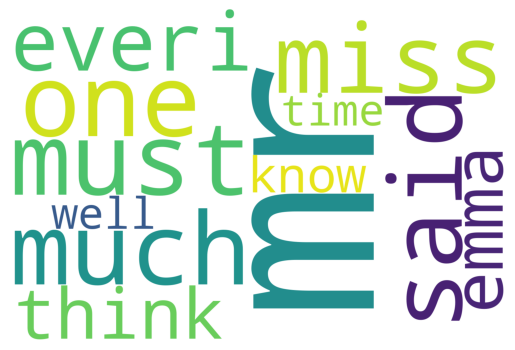

In [36]:
jane_austen = get_top_n_words(preprocess(books_per_author['austen']), 20)
word_list = []
frequencies = []

for word, frequency in jane_austen:
    word_list.append(word)
    frequencies.append(frequency)

plot_word_cloud(word_list)

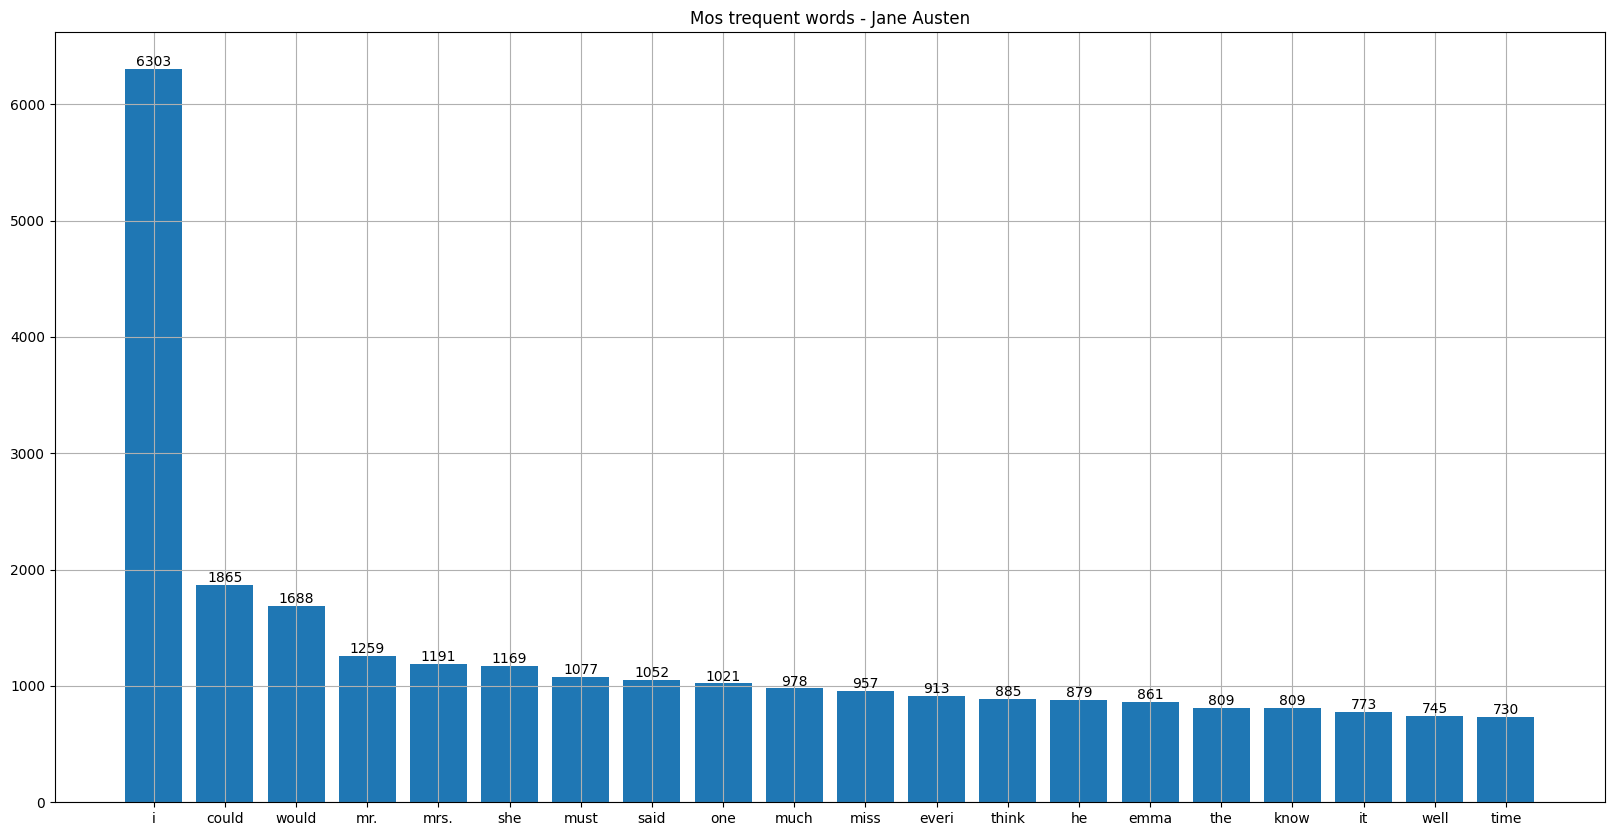

In [41]:
plt.figure(figsize=(20,10))
bars = plt.bar(word_list, frequencies)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{round(height, 3)}",
        ha="center",
        va="bottom"
    )
plt.title('Mos trequent words - Jane Austen')
plt.grid(True)
plt.show()

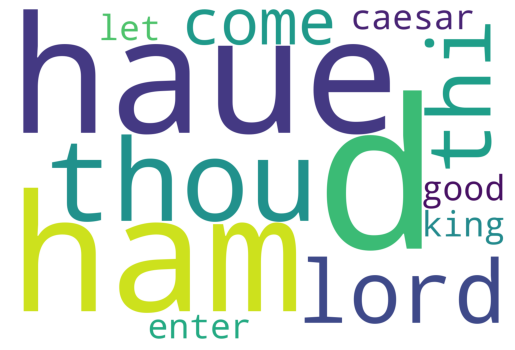

In [43]:
jane_austen = get_top_n_words(preprocess(books_per_author['shakespeare']), 20)
word_list = []
frequencies = []

for word, frequency in jane_austen:
    word_list.append(word)
    frequencies.append(frequency)

plot_word_cloud(word_list)

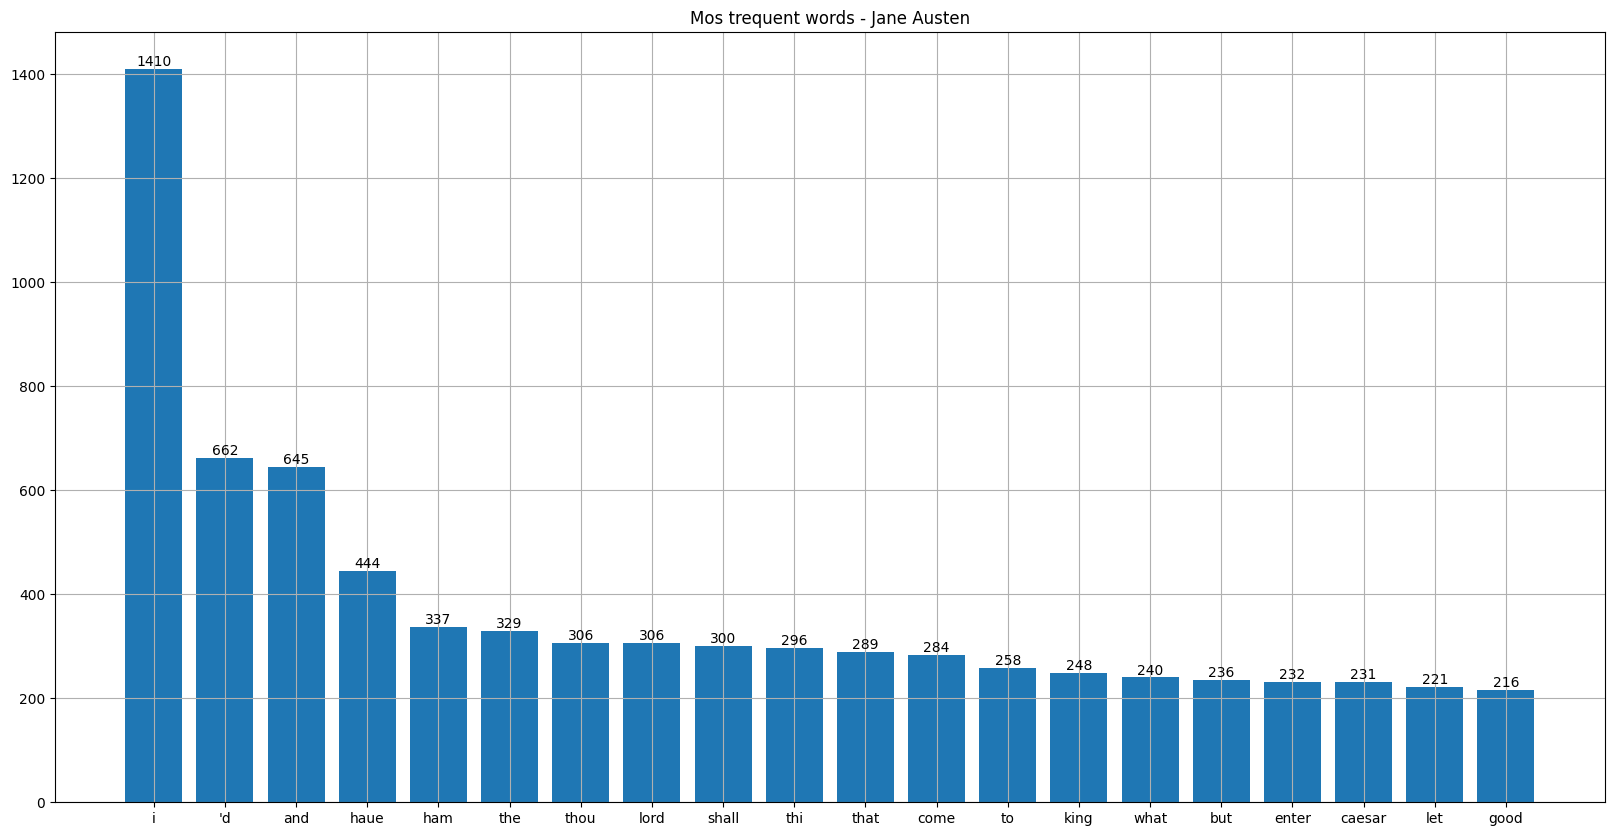

In [44]:
plt.figure(figsize=(20,10))
bars = plt.bar(word_list, frequencies)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{round(height, 3)}",
        ha="center",
        va="bottom"
    )
plt.title('Mos trequent words - Jane Austen')
plt.grid(True)
plt.show()

### Europarl Corpus

Reader for Europarl corpora that consist of plaintext documents. Documents are divided into chapters instead of paragraphs as for regular plaintext documents. Chapters are separated using blank lines. Everything is inherited from PlaintextCorpusReader except that:

    Since the corpus is pre-processed and pre-tokenized, the word tokenizer should just split the line at whitespaces.

    For the same reason, the sentence tokenizer should just split the paragraph at line breaks.

    There is a new ‘chapters()’ method that returns chapters instead instead of paragraphs.

    The ‘paras()’ method inherited from PlaintextCorpusReader is made non-functional to remove any confusion between chapters and paragraphs for Europarl.


In [71]:
def load_parallel_corpus(file1: str, file2: str) -> list:
    with open(file1, encoding="utf-8") as f1, open(file2, encoding="utf-8") as f2:
        lines1 = f1.readlines()
        lines2 = f2.readlines()
    
    # garantir mesmo tamanho
    assert len(lines1) == len(lines2)
    
    return list(zip(lines1, lines2))

In [67]:
with open("europarl_data/europarl-v7.pt-en.en", encoding="utf-8") as f:
    en_text = f.readlines()

with open("europarl_data/europarl-v7.pt-en.pt", encoding="utf-8") as f:
    pt_text = f.readlines()

In [73]:
pt_en = load_parallel_corpus("europarl_data/europarl-v7.pt-en.en", "europarl_data/europarl-v7.pt-en.pt")
pt_en

[('Resumption of the session\n', 'Reinício da sessão\n'),
 ('I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period.\n',
  'Declaro reaberta a sessão do Parlamento Europeu, que tinha sido interrompida na sexta-feira, 17 de Dezembro último, e renovo todos os meus votos, esperando que tenham tido boas férias.\n'),
 ("Although, as you will have seen, the dreaded 'millennium bug' failed to materialise, still the people in a number of countries suffered a series of natural disasters that truly were dreadful.\n",
  'Como puderam constatar, o grande "bug do ano 2000" não aconteceu. Em contrapartida, os cidadãos de alguns dos nossos países foram vítimas de catástrofes naturais verdadeiramente terríveis.\n'),
 ('You have requested a debate on this subject in the course of the next few days, during this part-session.\n',
  'Os senhores manifestar

!!!!!!! lembrar de subir isso pro git 